<a href="https://colab.research.google.com/github/MR-Goldenyt/Argus/blob/main/Argus.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


# IT7009 Artificial Intelligence - Selected Project Brief #2

## Intelligent Cyberattack Analysis System


## Phase 1: Data Cleaning and Preprocessing


### i. Imports and Data Loading


In [1]:
# Import Required Libraries
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Create the figures directory if it doesnt exist
os.makedirs("figures", exist_ok=True)

# Upload this file to the Colab session storage first
DATASET_PATH = "Dataset_Brief_2.csv"

# Raw dataset data frame for future comparisons with clean data
ddf = pd.read_csv(DATASET_PATH, low_memory=False)

# a copy of the raw dataset for cleaning
df = ddf.copy()

# Display the raw dataset
print("Raw dataset shape:", df.shape)
df.head()

Raw dataset shape: (48826, 47)


,flow_duration,Header_Length,Protocol Type,Duration,Rate,Srate,Drate,fin_flag_number,syn_flag_number,rst_flag_number,...,Std,Tot size,IAT,Number,Magnitue,Radius,Covariance,Variance,Weight,label
0,4.835233,1713517.54,16.89,66.33,634.919224,634.919224,0.0,0.0,0.0,0.0,...,23.51914405190254,540.23,8.375931e+07,9.5,32.983477,31.837886,3663.34722,0.14,141.55,Mirai-udpplain
1,0.000000,54.0,6.0,64.00,2.671835,2.671835,0.0,0.0,1.0,0.0,...,0.0,54.0,8.297303e+07,9.5,10.392305,0.000000,0.00000,0.0,141.55,DoS-SYN_Flood
2,0.000000,54.0,6.0,64.00,0.000000,0.000000,0.0,0.0,0.0,0.0,...,0.0,54.0,8.333120e+07,9.5,10.392305,0.000000,0.00000,0.0,141.55,DDoS-PSHACK_Flood
3,0.000000,0.0,1.0,64.00,160.127665,160.127665,0.0,0.0,0.0,0.0,...,0.0,42.0,8.312889e+07,9.5,9.165151,0.000000,0.00000,0.0,141.55,DDoS-ICMP_Flood
4,0.000000,54.0,6.0,64.00,1.262448,1.262448,0.0,1.0,0.0,1.0,...,0.0,54.0,8.334516e+07,9.5,10.392305,0.000000,0.00000,0.0,141.55,DDoS-RSTFINFlood


### ii. Overall Analysis of Raw Data


In [2]:
# Brief Information
print(df.info())

# Statistical Summary
df.describe(include="all").T.head(20)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48826 entries, 0 to 48825
Data columns (total 47 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   flow_duration    48815 non-null  float64
 1   Header_Length    48815 non-null  object 
 2   Protocol Type    48816 non-null  object 
 3   Duration         48816 non-null  float64
 4   Rate             48814 non-null  float64
 5   Srate            48816 non-null  float64
 6   Drate            48811 non-null  float64
 7   fin_flag_number  48814 non-null  float64
 8   syn_flag_number  48816 non-null  float64
 9   rst_flag_number  48815 non-null  float64
 10  psh_flag_number  48815 non-null  object 
 11  ack_flag_number  48814 non-null  float64
 12  ece_flag_number  48816 non-null  float64
 13  cwr_flag_number  48816 non-null  float64
 14  ack_count        48816 non-null  float64
 15  syn_count        48813 non-null  float64
 16  fin_count        48815 non-null  float64
 17  urg_count   

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
flow_duration,48815.0,NaN,NaN,NaN,14.495303,382.599894,-999.0,0.0,0.0,0.128624,47629.094561
Header_Length,48815,15623,54.0,14557,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Protocol Type,48816,915,6.0,22721,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Duration,48816.0,NaN,NaN,NaN,66.276401,12.9069,0.0,64.0,64.0,64.0,255.0
Rate,48814.0,NaN,NaN,NaN,8664.10689,89626.647942,-999.0,2.095422,15.69341,128.325003,3145728.0
Srate,48816.0,NaN,NaN,NaN,8663.824629,89624.823444,-999.0,2.095305,15.69341,128.351765,3145728.0
Drate,48811.0,NaN,NaN,NaN,0.000001,0.000089,0.0,0.0,0.0,0.0,0.014636
fin_flag_number,48814.0,NaN,NaN,NaN,0.083583,0.276764,0.0,0.0,0.0,0.0,1.0
syn_flag_number,48816.0,NaN,NaN,NaN,0.204359,0.403237,0.0,0.0,0.0,0.0,1.0
rst_flag_number,48815.0,NaN,NaN,NaN,0.088559,0.284109,0.0,0.0,0.0,0.0,1.0


### iii. Categorical, Temporal, and Identifier Audit


In [3]:
feature_cols = [c for c in df.columns if c != "label"]
print("Number of feature columns:", len(feature_cols))
print(f"\nColumn dtypes as read:\n{df.dtypes.value_counts()}")
print("\nAny column name suggesting an identifier/date field?")
suspect = [
    c
    for c in df.columns
    if any(k in c.lower() for k in ["id", "date", "time", "timestamp"])
    and c != "flow_duration"
]
print(
    suspect
    if suspect
    else "None found (besides the numeric duration/IAT features, which are not timestamps)."
)
print(
    "\nTarget classes:",
    df["label"].nunique(),
    "| Missing labels:",
    df["label"].isnull().sum(),
)

Number of feature columns: 46

Column dtypes as read:
float64    34
object     13
Name: count, dtype: int64

Any column name suggesting an identifier/date field?
None found (besides the numeric duration/IAT features, which are not timestamps).

Target classes: 33 | Missing labels: 0


### iv. Missing Values and Incorrect Data Types

`df.info()` above shows several columns that should be purely numeric (e.g. `Header_Length`,
`Protocol Type`, etc.) are instead read as `object` type. Inspecting the non-numeric
entries reveals the literal text tokens **`"invalid"`** and **`"unknown"`** planted inside otherwise
numeric cells not a genuine category.

**Proposed Solution:** replace these text tokens with `NaN`, then impute every feature column to numeric dtype.


======== Before ========
Total non-numeric values: 12
Total Missing values: 520
Identified 2 unique non-numeric (text) values: ['unknown' 'invalid']

======== After ========
Total non-numeric values: 0
Total Missing values: 532
Identified 0 unique non-numeric (text) values: []
New NaNs created by coercion: 12

======== Conclusion ========
All 46 feature columns are now numeric typed: True
Columns after cleaning (dtype before -> after):
01  Header_Length    object -> float64
02  Protocol Type    object -> float64
03  psh_flag_number  object -> float64
04  rst_count        object -> float64
05  HTTPS            object -> float64
06  ICMP             object -> float64
07  IPv              object -> float64
08  LLC              object -> float64
09  Min              object -> float64
10  Std              object -> float64
11  Tot size         object -> float64
12  Variance         object -> float64


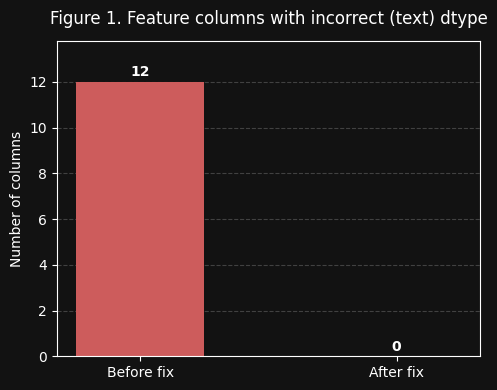

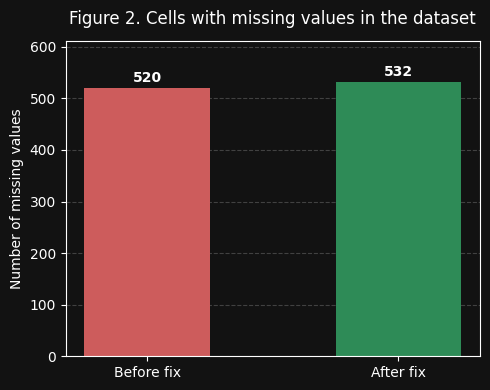

In [4]:
# bar chart background color 
BG = "#121212"

def coerce_numeric(raw):
    """Coerce columns to numeric; return (coerced frame, values that failed to parse)."""
    numeric = raw.apply(pd.to_numeric, errors="coerce")
    bad = raw.notna() & numeric.isna()  # had a value but became NaN
    return numeric, raw.to_numpy()[bad.to_numpy(dtype=bool)]

def print_col_types(cols, before, after):
    """Print indexed columns with their dtype change (before -> after)."""
    pad = len(str(len(cols)))               # zero-pad the index
    width = max(map(len, cols), default=0)  # align the dtype column
    for i, col in enumerate(cols, 1):
        # here we use an f string to format:
        # variable on the left side and styling properties on the right
        # the : (colon) seperates them
        print(f"{i:0{pad}d}  {col:<{width}}  {before[col]} -> {after[col]}")

def bar_before_after(values, title, ylabel, save_path=None):
    """Dark-style bar chart of a metric before vs after the fix."""
    style = ["dark_background", {"figure.facecolor": BG, "axes.facecolor": BG}]
    with plt.style.context(style):
        fig, ax = plt.subplots(figsize=(5, 4))
        ax.bar(["Before fix", "After fix"], values, color=["indianred", "seagreen"], width=0.5)
        ax.bar_label(ax.containers[0], fmt="%d", padding=2, fontweight="bold")
        ax.set_title(title, pad=12)
        ax.set_ylabel(ylabel)
        ax.set_ylim(0, max(values) * 1.15 or 1)  # headroom so labels aren't clipped
        ax.grid(axis="y", linestyle="--", alpha=0.2)
        ax.set_axisbelow(True)
        fig.tight_layout()
        if save_path:
            fig.savefig(save_path, dpi=240, facecolor=BG)
    plt.close(fig)
    return fig

# ======== Before ========
# Get text columns 
object_cols_before = (
    df[feature_cols].select_dtypes(include="object").columns.to_list()  # "str" avoids pandas warning
)
raw = df[object_cols_before]
dtypes_before = raw.dtypes
missing_values_before = df.isna().to_numpy().sum()
numeric, non_numbers_before = coerce_numeric(raw)
unique_non_numbers_before = pd.unique(non_numbers_before)

print("======== Before ========")
print("Total non-numeric values:", len(non_numbers_before))
print("Total Missing values:", missing_values_before)
print(f"Identified {len(unique_non_numbers_before)} unique non-numeric (text) values: {unique_non_numbers_before}")

# ======== Cleaning ========
# bad values become NaN
df[object_cols_before] = numeric

# ======== After ========
missing_values_after = df.isna().to_numpy().sum()
object_cols_after = df[feature_cols].select_dtypes(include="object").columns.to_list()
_, non_numbers_after = coerce_numeric(df[object_cols_after])
unique_non_numbers_after = pd.unique(non_numbers_after)

print("\n======== After ========")
print("Total non-numeric values:", len(non_numbers_after))
print("Total Missing values:", missing_values_after)
print(f"Identified {len(unique_non_numbers_after)} unique non-numeric (text) values: {unique_non_numbers_after}")
print("New NaNs created by coercion:", missing_values_after - missing_values_before)

print("\n======== Conclusion ========")
print(f"All {len(feature_cols)} feature columns are now numeric typed:", not object_cols_after)
print("Columns after cleaning (dtype before -> after):")
print_col_types(object_cols_before, dtypes_before, df[object_cols_before].dtypes)

# ======== Figures ========
fig1 = bar_before_after(
    [len(object_cols_before), len(object_cols_after)],
    "Figure 1. Feature columns with incorrect (text) dtype",
    "Number of columns",
    # save_path="figures/fig1_dtype_fix.png",
)
fig2 = bar_before_after(
    [missing_values_before, missing_values_after],
    "Figure 2. Cells with missing values in the dataset",
    "Number of missing values",
    # save_path="figures/fig2_missing_values.png",
)

# display them because they dont appear in vscode
display(fig1)
display(fig2)

### v. Detecting and Fixing Outliers using Interquartile Range (IQR)

### v. Detecting and Fixing Outliers using Interquartile Range (IQR)

Outliers are flagged with the IQR rule: a value is an outlier if it falls outside the lower or upper bounds **[Q1 − 1.5 × IQR, Q3 + 1.5 × IQR]**, where IQR = Q3 − Q1.

Two kinds of columns cannot be judged this way and are **reported but not treated**: binary flags (0/1) and columns whose IQR is 0, because every non-typical value would be flagged as an outlier.

**Proposed Solution:** rather than dropping rows, values are **capped** at the fences, so no records are lost.
Figure 4 shows how many rows each attack class would lose if outlier rows were dropped instead.
Set `OUTLIER_ACTION = "none"` to assess only, or raise `IQR_K` (e.g. 3.0) for a more conservative rule.